<a href="https://colab.research.google.com/github/ThisalFernando/Fake-Real-News-Detection/blob/Multinominal_Naive_Bayes/Multinominal_Naive_Bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cell 1: Imports + Mount Drive + Load dataset (Google Colab)

In [21]:
import pandas as pd
import numpy as np
import re

from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, log_loss, classification_report, confusion_matrix
)

import matplotlib.pyplot as plt

# 1) Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# 2) Set the dataset path
CSV_PATH = "/content/drive/MyDrive/improved_fake_news_dataset2.csv"

# 3) Load dataset
df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head(5)

Mounted at /content/drive
Shape: (123954, 4)
Columns: ['id', 'title', 'text', 'label']


,id,title,text,label
0,156735,NaN,Embargo on Phillipines - withdraw our military...,1
1,212890,Especially sea lay son hear.,too win central main bag save common she famil...,1
2,183407,Russian oil giant Rosneft to restore Romanov p...,Russian oil giant Rosneft to restore Romanov p...,1
3,199095,NaN,the club world cup is here our representative ...,0
4,228061,NaN,"the ismaili club s board of directors, headed ...",1


# Cell 2: Basic cleaning + combine title and text

In [22]:
import re

TITLE_COL = "title"
TEXT_COL  = "text"
LABEL_COL = "label"

missing_cols = [c for c in [TITLE_COL, TEXT_COL, LABEL_COL] if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}. Found: {df.columns.tolist()}")

def clean_text_safe(s: str) -> str:
    s = "" if pd.isna(s) else str(s)

    # remove HTML tags only
    s = re.sub(r"<[^>]+>", " ", s)

    # normalize whitespace only
    s = re.sub(r"\s+", " ", s).strip()
    return s

df[TITLE_COL] = df[TITLE_COL].fillna("")
df[TEXT_COL]  = df[TEXT_COL].fillna("")

df["content"] = (df[TITLE_COL].map(clean_text_safe) + " " + df[TEXT_COL].map(clean_text_safe)).str.strip()

df[LABEL_COL] = pd.to_numeric(df[LABEL_COL], errors="coerce")
df = df.dropna(subset=[LABEL_COL]).copy()
df[LABEL_COL] = df[LABEL_COL].astype(int)

print("After preprocessing shape:", df.shape)
print("Label counts:\n", df[LABEL_COL].value_counts())
df[["content", LABEL_COL]].head()

After preprocessing shape: (123954, 5)
Label counts:
 label
1    61977
0    61977
Name: count, dtype: int64


,content,label
0,Embargo on Phillipines - withdraw our military...,1
1,Especially sea lay son hear. too win central m...,1
2,Russian oil giant Rosneft to restore Romanov p...,1
3,the club world cup is here our representative ...,0
4,"the ismaili club s board of directors, headed ...",1


# Cell 3: Train/Test split

In [23]:
X = df["content"].values
y = df[LABEL_COL].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

print("Train label distribution:", np.bincount(y_train))
print("Test label distribution:", np.bincount(y_test))

Train size: 99163
Test size: 24791
Train label distribution: [49581 49582]
Test label distribution: [12396 12395]


# Cell 4: Build model pipeline and train

In [24]:
model = Pipeline(steps=[
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95
    )),
    ("nb", MultinomialNB(alpha=1.0))
])

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


# Cell 5: Evaluate metrics on test set

In [25]:
# Predicted class labels
y_pred = model.predict(X_test)

# Predicted probabilities for positive class (needed for ROC_AUC + log loss)
y_proba = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

# ROC AUC requires both classes present in y_test; handle edge case
try:
    roc_auc = roc_auc_score(y_test, y_proba)
except ValueError as e:
    roc_auc = None
    print("ROC_AUC could not be computed:", e)

val_loss = log_loss(y_test, y_proba)

print("=== Test Metrics (MultinomialNB) ===")
print(f"Accuracy        : {acc:.4f}")
print(f"Precision       : {prec:.4f}")
print(f"Recall          : {rec:.4f}")
print(f"F1-score        : {f1:.4f}")
print(f"ROC_AUC         : {roc_auc:.4f}" if roc_auc is not None else "ROC_AUC         : N/A")
print(f"Validation Loss : {val_loss:.4f}  (Log Loss)")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

=== Test Metrics (MultinomialNB) ===
Accuracy        : 0.8132
Precision       : 0.8965
Recall          : 0.7080
F1-score        : 0.7912
ROC_AUC         : 0.8979
Validation Loss : 0.4140  (Log Loss)

Confusion Matrix:
[[11383  1013]
 [ 3619  8776]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7588    0.9183    0.8309     12396
           1     0.8965    0.7080    0.7912     12395

    accuracy                         0.8132     24791
   macro avg     0.8276    0.8132    0.8111     24791
weighted avg     0.8276    0.8132    0.8111     24791



# ROC Curve and AUC score

ROC AUC Score: 0.8979


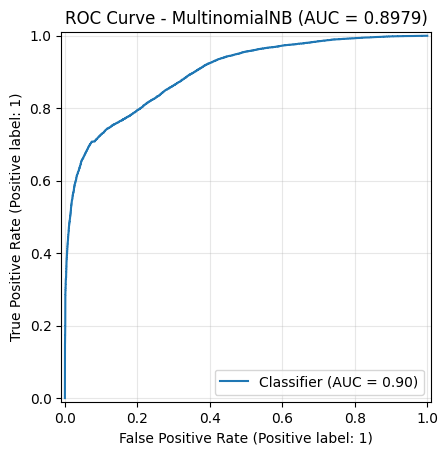

In [26]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

auc = roc_auc_score(y_test, y_proba)
print(f"ROC AUC Score: {auc:.4f}")

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title(f"ROC Curve - MultinomialNB (AUC = {auc:.4f})")
plt.grid(True, alpha=0.3)
plt.show()

# Gradio Interface

In [28]:
!pip -q install gradio

import gradio as gr
import numpy as np

LABEL_MAP = {1: "Real", 0: "Fake"}

def predict_news(title, text):
    combined = f"{title} {text}".strip()

    proba = model.predict_proba([combined])[0]     # [p(class0), p(class1)]
    pred = int(np.argmax(proba))

    return {
        f"{LABEL_MAP.get(0,'Class 0')} (0)": float(proba[0]),
        f"{LABEL_MAP.get(1,'Class 1')} (1)": float(proba[1]),
        "Predicted Label": LABEL_MAP.get(pred, str(pred))
    }

demo = gr.Interface(
    fn=predict_news,
    inputs=[
        gr.Textbox(label="Title", placeholder="Enter the news title here..."),
        gr.Textbox(label="Text", lines=8, placeholder="Paste the news content here...")
    ],
    outputs=gr.JSON(label="Prediction"),
    title="Fake vs Real News Detection (TF-IDF + Naive Bayes)",
    description="Enter a news title and body text to get a prediction + class probabilities."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://243c3bfac42b86c115.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
